In [1]:
import torch

In [2]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

In [3]:
from torchvision.datasets import FashionMNIST

fm_train = FashionMNIST(root='.', train=True, download=True)
fm_test = FashionMNIST(root='.', train=False, download=True)

In [4]:
print(fm_train.data.shape, fm_test.data.shape)
print(fm_train.targets.shape, fm_test.targets.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])
torch.Size([60000]) torch.Size([10000])


In [5]:
train_input = fm_train.data
train_target = fm_train.targets

In [6]:
train_scaled = train_input / 255.0

In [7]:
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

In [8]:
print(train_scaled.shape, val_scaled.shape)

torch.Size([48000, 28, 28]) torch.Size([12000, 28, 28])


In [9]:
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(), # 입력층
    nn.Linear(784,100), # 은닉층
    nn.ReLU(), # 활성함수
    nn.Dropout(0.3),
    nn.Linear(100,10) # 출력층
)

In [10]:
from torchinfo import summary

summary(model, input_size=(32,28,28)) # 32 : batch size, 28,28 : 이미지 사이즈

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 10]                  --
├─Flatten: 1-1                           [32, 784]                 --
├─Linear: 1-2                            [32, 100]                 78,500
├─ReLU: 1-3                              [32, 100]                 --
├─Dropout: 1-4                           [32, 100]                 --
├─Linear: 1-5                            [32, 10]                  1,010
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.54
Input size (MB): 0.10
Forward/backward pass size (MB): 0.03
Params size (MB): 0.32
Estimated Total Size (MB): 0.45

In [11]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)
model.to(device) # GPU에서 실행 되도록 한다.

device = cuda


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=100, out_features=10, bias=True)
)

In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # 다중 분류, 이진분류: nn.BCELoss 또는 nn.BCEWithLogitsLoss
optimizer = optim.Adam(model.parameters())

In [13]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 2# 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 20
batches = int(len(train_scaled)/32)
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for i in range(batches): # 1 epoch 실행
        inputs = train_scaled[i*32:(i+1)*32].to(device) # 배치 입력 데이터 준비
        targets = train_target[i*32:(i+1)*32].to(device) # 배치 데이터에 대한 정답 준비
        optimizer.zero_grad() # 이전에 계산된 기울기값 초기화하는 함수
        outputs = model(inputs) # 모델에 입력 데이터 전달
        loss = criterion(outputs, targets) # 손실값 계산
        loss.backward() # 각 층의 모델 파라메터에 대한 기울기(그레디언트)를 계산
        optimizer.step() # 손실 파라메터 업데이트 
        train_loss += loss.item() # 손실값 기록, item(): 파이토치 텐서로부터 값을 추출
    
    model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
    val_loss = 0
    with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
        val_scaled = val_scaled.to(device) # 검증용 데이터 GPU로 전송
        val_target = val_target.to(device) # 검증용 데이터에 대한 정답 GPU로 전송
        outputs = model(val_scaled)
        loss = criterion(outputs, val_target)
        val_loss = loss.item()
        
    train_hist.append(train_loss/batches)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},", f"훈련 손실:{train_loss/batches:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.6031, 검증 손실:0.4344
에포크:2, 훈련 손실:0.4415, 검증 손실:0.3981
에포크:3, 훈련 손실:0.4023, 검증 손실:0.3699
에포크:4, 훈련 손실:0.3820, 검증 손실:0.3614
에포크:5, 훈련 손실:0.3675, 검증 손실:0.3564
에포크:6, 훈련 손실:0.3540, 검증 손실:0.3472
에포크:7, 훈련 손실:0.3439, 검증 손실:0.3388
에포크:8, 훈련 손실:0.3363, 검증 손실:0.3308
에포크:9, 훈련 손실:0.3255, 검증 손실:0.3362
에포크:10, 훈련 손실:0.3218, 검증 손실:0.3397
10번째 에포크에서 조기 종료되었습니다.


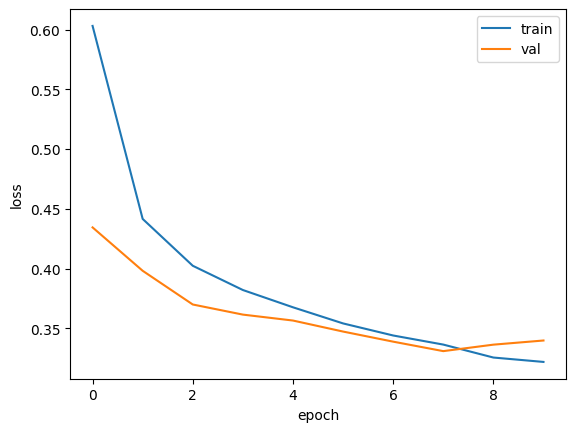

In [18]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [15]:
model.load_state_dict(torch.load('best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [16]:
model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
    val_scaled = val_scaled.to(device) # 검증용 데이터 GPU로 전송
    val_target = val_target.to(device) # 검증용 데이터에 대한 정답 GPU로 전송
    outputs = model(val_scaled)
    # torch.argmax(): 1번째 차원(가로 행 방향)을 기준으로 가장 큰 값을 가진 원소의 인덱스(위치)를 반환
    predicts = torch.argmax(outputs, 1)
    corrects = (predicts == val_target).sum().item() # 일치하는 데이터 카운트

accuracy = corrects / len(val_target) # 정확도 계산
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.8814
